<a href="https://colab.research.google.com/github/Divyanshi082004/ml-project/blob/dev/NetflixData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

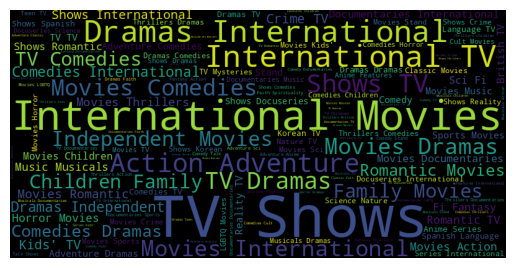

In [48]:
from wordcloud import WordCloud

text = " ".join(df['listed_in'])
wordcloud = WordCloud(width=800, height=400).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [49]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import os


Load Data set


In [50]:
df = pd.read_csv("netflix_titles.csv")

In [51]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


Basic Cleaning

In [52]:
df.shape

(8807, 12)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [54]:
df.isnull()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,False,False,False,False,True,False,False,False,False,False,False,False
1,False,False,False,True,False,False,False,False,False,False,False,False
2,False,False,False,False,False,True,False,False,False,False,False,False
3,False,False,False,True,True,True,False,False,False,False,False,False
4,False,False,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,False,False,False,False,False,False,False,False,False,False,False,False
8803,False,False,False,True,True,True,False,False,False,False,False,False
8804,False,False,False,False,False,False,False,False,False,False,False,False
8805,False,False,False,False,False,False,False,False,False,False,False,False


In [55]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [56]:
df.duplicated().sum()

np.int64(0)

In [57]:
df['director'].value_counts().head(10)

,count
director,
Rajiv Chilaka,19
"Raúl Campos, Jan Suter",18
Suhas Kadav,16
Marcus Raboy,16
Jay Karas,14
Cathy Garcia-Molina,13
Martin Scorsese,12
Youssef Chahine,12
Jay Chapman,12


Clean Data

In [58]:
df.drop_duplicates(inplace=True)

df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')

df['country'] = df['country'].fillna("Unknown")
df['director'] = df['director'].fillna("Unknown")

EDA

In [59]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


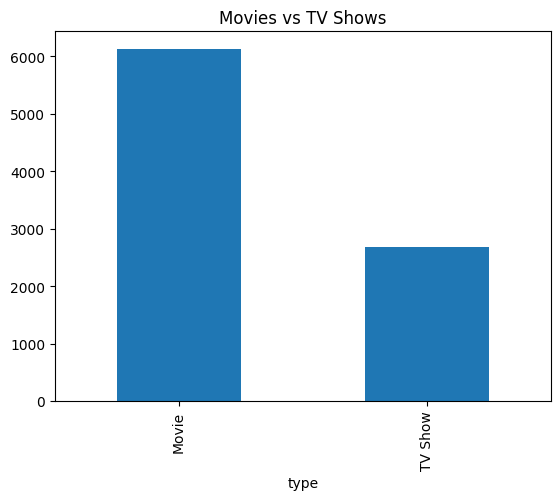

In [60]:
import matplotlib.pyplot as plt

df['type'].value_counts().plot(kind='bar')
plt.title("Movies vs TV Shows")
plt.show()

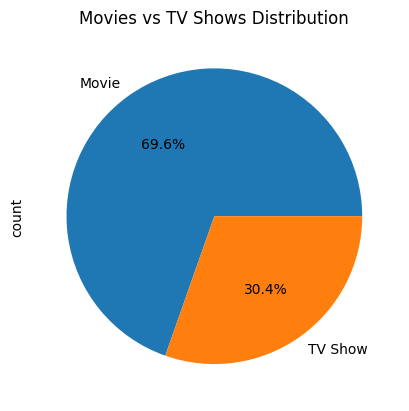

In [61]:
df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Movies vs TV Shows Distribution")
plt.show()

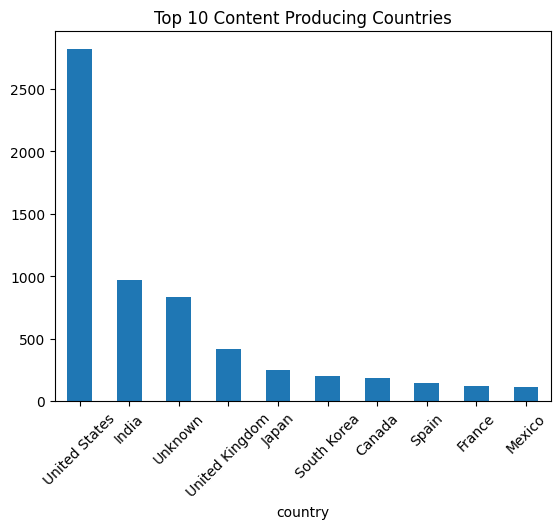

In [62]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Content Producing Countries")
plt.xticks(rotation=45)
plt.show()

Year Analysis

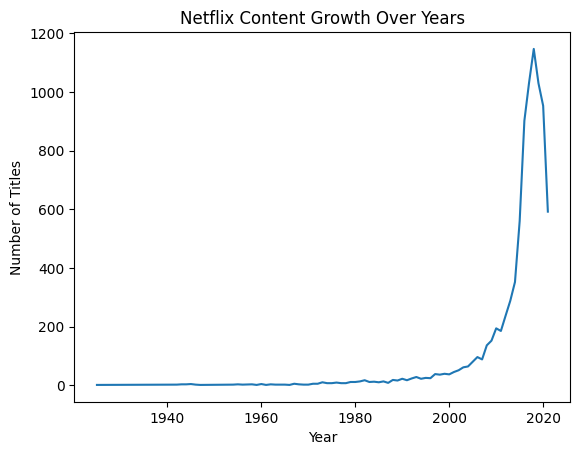

In [63]:
df['release_year'].value_counts().sort_index().plot(kind='line')
plt.title("Netflix Content Growth Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

Genre Analysis


In [64]:
df['listed_in'].value_counts().head(10)


,count
listed_in,
"Dramas, International Movies",362
Documentaries,359
Stand-Up Comedy,334
"Comedies, Dramas, International Movies",274
"Dramas, Independent Movies, International Movies",252
Kids' TV,220
Children & Family Movies,215
"Children & Family Movies, Comedies",201
"Documentaries, International Movies",186


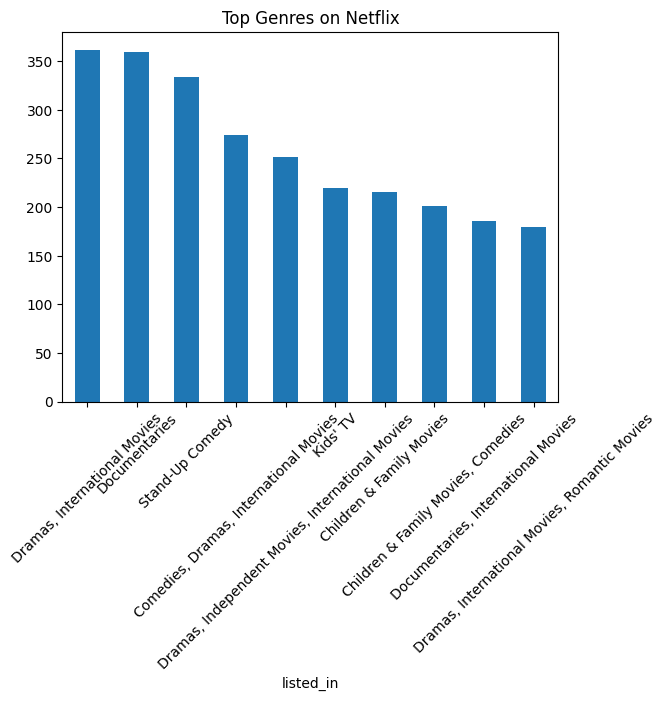

In [65]:
df['listed_in'].value_counts().head(10).plot(kind='bar')
plt.title("Top Genres on Netflix")
plt.xticks(rotation=45)
plt.show()

Ratings Analysis

In [66]:
df['rating'].value_counts()

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


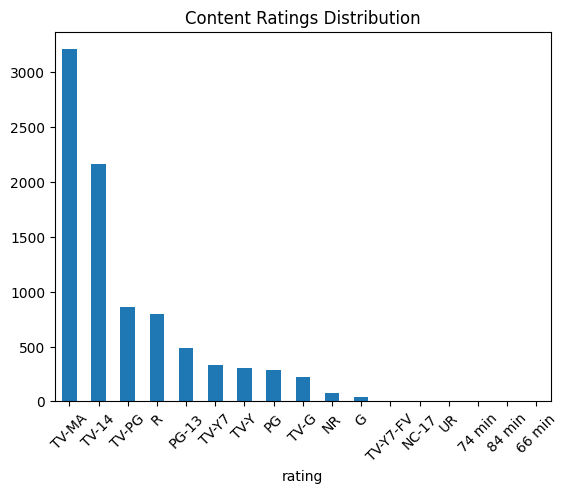

In [67]:
df['rating'].value_counts().plot(kind='bar')
plt.title("Content Ratings Distribution")
plt.xticks(rotation=45)
plt.show()

💡 Business Insights & Recommendations

📊 Movies vs TV Shows
Netflix has more Movies than TV Shows
Users prefer short-form content
💡 Recommendation: Invest more in mini-series

🌍 Country Analysis
USA dominates content production
💡 Recommendation: Add more regional content (India, Korea, Europe)

📅 Content Trend
Content increased after 2015
💡 Recommendation: Maintain balanced growth strategy

🎭 Genres
Drama & International Movies are most common
💡 Recommendation: Diversify genres for wider audience

⭐ Ratings
TV-MA is most frequent rating
💡 Recommendation: Improve family-friendly content

In [68]:
## 🏁 Conclusion
#This project analyzed Netflix dataset to understand content distribution, trends, and audience preferences. The insights can help improve content strategy and decision making.